# zkLLM (CCS 2024) — Reproduction Notebook

Reproduces the **Table 1** experiment from [arXiv:2404.16109](https://arxiv.org/abs/2404.16109) on the *fixed* fork in this workspace.

Targets **LLaMa-2-7B and 13B**, all transformer layers, sequence length 2048, scaling factor `2^16`. Captures committing time, commitment size, prover time, proof size, verifier time, peak GPU memory, and (optionally) C4 perplexity drop. Compares against the paper's published numbers at the end.

**Run order**: execute cells top-to-bottom. The notebook is idempotent — stages whose `.proof` already exists are skipped, so a kernel restart resumes mid-run.

**Hardware assumed**: Linux with CUDA 12.x, NVIDIA A100 (40 GB) per the paper. For a different GPU, change `GPU_ARCH` in the parameter cell.

## Phase A — Environment & Build

In [8]:
# Cell 1 — Top-level parameters.
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
assert (REPO_ROOT / 'Makefile').exists(), f'Run this notebook from the repo root, not {REPO_ROOT}'

MODEL_SIZES        = [7, 13]              # paper Table 1 reports both
SEQ_LEN            = 2048                 # paper sequence length
LOG_SF             = 16                   # log scaling factor (only 16 is tested in this fork)
GPU_ARCH           = 'sm_80'              # A100. Change to sm_86 for A6000/RTX-30, sm_90 for H100.
LAYER_LIMIT        = None                 # int → only run first N layers (smoke test). None → all layers.
RUN_PERPLEXITY     = True                 # set False to skip the C4 perplexity cells
PERPLEXITY_SAMPLES = 64                   # number of 2048-token C4 windows to score (paper: full validation set)
KEEP_INTERMEDIATE  = False                # delete per-layer .bin activations after each layer to save disk
WORK_DIR           = REPO_ROOT / 'work'   # per-layer outputs land here
RESULTS_DIR        = REPO_ROOT / 'results'
WORK_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print(f'Repo root      : {REPO_ROOT}')
print(f'Model sizes    : {MODEL_SIZES}')
print(f'Sequence length: {SEQ_LEN}')
print(f'GPU arch       : {GPU_ARCH}')
print(f'Layer limit    : {LAYER_LIMIT or "all"}')
print(f'Perplexity     : {RUN_PERPLEXITY} ({PERPLEXITY_SAMPLES} samples)')
print(f'Keep .bin      : {KEEP_INTERMEDIATE}')

Repo root      : /lambda/nfs/zero-knowledge-virginia/zkllm-ccs2024-fixed
Model sizes    : [7, 13]
Sequence length: 2048
GPU arch       : sm_80
Layer limit    : all
Perplexity     : True (64 samples)
Keep .bin      : False


In [9]:
# Cell 1.5 — Install Python dependencies (idempotent).
# Skips packages that are already importable; otherwise installs into the active env.
import importlib, subprocess, sys

# Map: import name -> pip spec (pinned to versions known to work with this fork's
# hard-coded LLaMa-2 loading code). transformers >= 4.45 changed rotary_emb's
# signature in a way llama-self-attn.py does not handle, so we pin <= 4.44.
REQUIRED = [
    ('torch',         'torch'),
    ('transformers',  'transformers==4.44.2'),
    ('datasets',      'datasets'),
    ('numpy',         'numpy'),
    ('pandas',        'pandas'),
    ('matplotlib',    'matplotlib'),
    ('huggingface_hub','huggingface_hub'),
    ('sentencepiece', 'sentencepiece'),    # required by LLaMa tokenizer
    ('accelerate',    'accelerate'),       # used by from_pretrained device_map
    ('protobuf',      'protobuf'),         # tokenizer dependency
]

preinstalled = {mod for mod, _ in REQUIRED if mod in sys.modules}
missing = []
for mod, spec in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append((mod, spec))

if missing:
    print('Installing:', [s for _, s in missing])
    cmd = [sys.executable, '-m', 'pip', 'install', '-q', *(s for _, s in missing)]
    rc = subprocess.call(cmd)
    if rc != 0:
        raise RuntimeError(f'pip install failed (rc={rc}): {missing}')
    # Import each newly-installed package once so subsequent cells find it.
    # IMPORTANT: do NOT reload torch / other C-extension packages that were
    # already loaded — re-executing their module body re-registers TORCH_LIBRARY
    # bindings and crashes the kernel. Only fresh-import the modules that
    # weren't loaded before this cell ran.
    for mod, _ in missing:
        if mod not in sys.modules:
            try:
                importlib.import_module(mod)
            except Exception as e:
                print(f'  warn: post-install import {mod} failed: {e}')
    # If a previously-loaded package was upgraded (e.g. transformers), warn
    # the user to restart the kernel rather than silently reloading it.
    upgraded_loaded = [m for m, _ in missing if m in preinstalled]
    if upgraded_loaded:
        print(f'\nNOTE: these were already loaded and got upgraded: {upgraded_loaded}.')
        print('      Restart the kernel before continuing for the new versions to take effect.')
else:
    print('All required packages already installed.')

# Quick version sanity print.
import torch, transformers, datasets, numpy, pandas
print(f'torch={torch.__version__}  transformers={transformers.__version__}  '
      f'datasets={datasets.__version__}  numpy={numpy.__version__}  pandas={pandas.__version__}')


Installing: ['protobuf']
  warn: post-install import protobuf failed: No module named 'protobuf'
torch=2.7.0  transformers=4.44.2  datasets=4.8.5  numpy=1.21.5  pandas=1.3.5


In [ ]:
# Cell 2 — Environment sanity + Hugging Face token.
import os, sys, shutil, subprocess

# Sanity: torch + CUDA + transformers.
import torch, transformers
print(f'Python      : {sys.version.split()[0]}')
print(f'torch       : {torch.__version__}')
print(f'transformers: {transformers.__version__}')
print(f'CUDA avail. : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU 0       : {torch.cuda.get_device_name(0)}')
assert torch.cuda.is_available(), 'CUDA GPU is required by zkLLM kernels'

# Tooling sanity.
for tool in ('nvcc', 'make', 'nvidia-smi'):
    if shutil.which(tool) is None:
        print(f'WARNING: {tool} not on PATH')
    else:
        print(f'{tool:11s} : {shutil.which(tool)}')

# HF token (only prompted on first run if not already set).
if not os.environ.get('HF_TOKEN'):
    os.environ['HF_TOKEN'] = "YOUR_HF_TOKEN_HERE"
assert os.environ['HF_TOKEN'].startswith('hf_'), 'token should start with hf_'
print('HF_TOKEN set (', len(os.environ['HF_TOKEN']), 'chars )')

Python      : 3.10.12
torch       : 2.7.0
transformers: 4.44.2
CUDA avail. : True
GPU 0       : NVIDIA A100-SXM4-40GB
nvcc        : /usr/bin/nvcc
make        : /usr/bin/make
nvidia-smi  : /usr/bin/nvidia-smi
HF_TOKEN set ( 37 chars )


In [11]:
# Cell 3 — Patch Makefile ARCH if needed (idempotent).
mk_path = REPO_ROOT / 'Makefile'
src = mk_path.read_text()
import re
m = re.search(r'^ARCH\s*:=\s*(\S+)\s*$', src, flags=re.MULTILINE)
assert m, 'Could not find ARCH := ... line in Makefile'
current = m.group(1)
if current == GPU_ARCH:
    print(f'Makefile ARCH already = {GPU_ARCH}, no patch needed')
else:
    new = re.sub(r'^ARCH\s*:=\s*\S+\s*$', f'ARCH := {GPU_ARCH}', src, count=1, flags=re.MULTILINE)
    mk_path.write_text(new)
    print(f'Makefile ARCH patched: {current} -> {GPU_ARCH}')

Makefile ARCH patched: sm_86 -> sm_80


In [31]:
# Cell 4 — Build all CUDA targets.
import time
_t0 = time.perf_counter()
proc = subprocess.run(['make', '-j', 'all'], cwd=REPO_ROOT, capture_output=True, text=True)
build_seconds = time.perf_counter() - _t0
print(proc.stdout[-4000:])
if proc.returncode != 0:
    print('--- STDERR ---')
    print(proc.stderr[-4000:])
    raise RuntimeError(f'make failed (rc={proc.returncode})')
print(f'\nbuild took {build_seconds:.1f} s')
for t in ('main','ppgen','commit-param','self-attn','ffn','rmsnorm','skip-connection'):
    p = REPO_ROOT / t
    assert p.exists() and os.access(p, os.X_OK), f'binary {t} missing or not executable'
    print(f'  ok  {t:18s} {p.stat().st_size:>10,} B')

/bin/nvcc -arch=sm_80 -std=c++17 -I/include -dc -dlto main.cu -o main.o
/bin/nvcc -arch=sm_80 -std=c++17 -I/include -L/lib main.o bls12-381.o ioutils.o commitment.o fr-tensor.o g1-tensor.o proof.o zkrelu.o zkfc.o tlookup.o polynomial.o zksoftmax.o rescaling.o timer.o -o main -dlto


build took 119.2 s
  ok  main               21,316,672 B
  ok  ppgen              21,263,288 B
  ok  commit-param       21,267,424 B
  ok  self-attn          21,313,440 B
  ok  ffn                21,283,680 B
  ok  rmsnorm            21,283,600 B
  ok  skip-connection    21,279,496 B


In [13]:
# Cell 5 — Helper utilities used by every subsequent stage.
import json, threading, time, subprocess
from dataclasses import dataclass, asdict, field
from typing import List, Optional

@dataclass
class StageResult:
    label: str
    layer: Optional[int]
    wall_s: float
    peak_mem_mb: float
    returncode: int
    stdout_tail: str
    stderr_tail: str

def _gpu_mem_mb():
    """Return current GPU 0 memory used (MiB) via nvidia-smi."""
    try:
        out = subprocess.check_output(
            ['nvidia-smi','--query-gpu=memory.used','--format=csv,noheader,nounits','-i','0'],
            text=True, timeout=2)
        return float(out.strip().splitlines()[0])
    except Exception:
        return 0.0

def run_stage(cmd, label, layer=None, env_extra=None, cwd=None, poll_hz=2.0):
    """Run a subprocess, time it, sample GPU mem in a side thread, return StageResult."""
    env = os.environ.copy()
    if env_extra:
        env.update(env_extra)
    peak = {'mb': 0.0}
    stop = threading.Event()
    def _poll():
        while not stop.is_set():
            v = _gpu_mem_mb()
            if v > peak['mb']:
                peak['mb'] = v
            time.sleep(1.0 / poll_hz)
    th = threading.Thread(target=_poll, daemon=True)
    th.start()
    t0 = time.perf_counter()
    try:
        proc = subprocess.run(cmd, cwd=cwd or REPO_ROOT, env=env,
                              capture_output=True, text=True)
    finally:
        stop.set(); th.join()
    wall = time.perf_counter() - t0
    res = StageResult(
        label=label, layer=layer, wall_s=wall, peak_mem_mb=peak['mb'],
        returncode=proc.returncode,
        stdout_tail=proc.stdout[-2000:], stderr_tail=proc.stderr[-2000:],
    )
    return res

def append_jsonl(path, record):
    with open(path, 'a') as f:
        f.write(json.dumps(record, default=str) + '\n')

def workdir_for(model_size):
    return REPO_ROOT / 'zkllm-workdir' / f'Llama-2-{model_size}b'

def activation_generator_for(model_size):
    """
    Generator file used as ZKLLM_ACTIVATION_GEN and as skip-connection's
    --generator_file. We reuse input_layernorm.weight-pp.bin: its size equals
    embed_dim, which divides every activation tensor of shape seq_len*embed_dim
    cleanly, satisfying the 'tensor.size %% gen.size == 0' requirement of
    skip-connection.cu and stage_proof.cuh.
    """
    return workdir_for(model_size) / 'input_layernorm.weight-pp.bin'

print('Helpers loaded.')

Helpers loaded.


In [14]:
# Cell 6 — Patch llama-self-attn.py (idempotent).
#
# Two demo-script issues we work around without touching the C++ kernels:
#   (1) self-attn 'attn' mode writes its output to temp_head_out.bin and the
#       wrapper's `rm ./temp*.bin` deletes it before the next stage can read
#       it. We copy temp_head_out.bin (and its .com sidecar) to the requested
#       output_file BEFORE the rm.
#   (2) self-attn 'linear' and 'attn' both write <output>.proof, so the
#       linear proof is overwritten. We move the linear .proof aside to
#       <output>.linear.proof before the attn call.
import shutil, re, textwrap
self_attn_py = REPO_ROOT / 'llama-self-attn.py'
src = self_attn_py.read_text()
MARK = '# === reproduction-notebook patch ==='
if MARK in src:
    print('llama-self-attn.py already patched, skipping')
else:
    backup = self_attn_py.with_suffix('.py.orig')
    if not backup.exists():
        shutil.copy2(self_attn_py, backup)
        print(f'backup -> {backup.name}')
    # Insert linear-proof-preserving copy after the linear ./self-attn call.
    linear_call = "os.system(f'./self-attn linear {args.input_file} {args.seq_len} {embed_dim} {workdir} {layer_prefix} {args.output_file}')"
    insert_after_linear = (
        linear_call + '\n'
        '    ' + MARK + '\n'
        '    import shutil as _sh\n'
        "    if os.path.isfile(args.output_file + '.proof'):\n"
        "        _sh.copy2(args.output_file + '.proof', args.output_file + '.linear.proof')\n"
    )
    assert src.count(linear_call) == 1, 'expected exactly one linear self-attn invocation'
    src = src.replace(linear_call, insert_after_linear)
    # Replace the cleanup rm with: copy temp_head_out.bin -> output_file, then rm.
    rm_call = "os.system('rm ./temp*.bin')"
    replace_rm = (
        MARK + '\n'
        '    import shutil as _sh\n'
        "    if os.path.isfile('temp_head_out.bin'):\n"
        "        _sh.copy2('temp_head_out.bin', args.output_file)\n"
        "    if os.path.isfile('temp_head_out.bin.com'):\n"
        "        _sh.copy2('temp_head_out.bin.com', args.output_file + '.com')\n"
        '    ' + rm_call
    )
    assert src.count(rm_call) == 1, 'expected exactly one rm temp invocation'
    src = src.replace(rm_call, replace_rm)
    self_attn_py.write_text(src)
    print('llama-self-attn.py patched')

backup -> llama-self-attn.py.orig
llama-self-attn.py patched


## Phase B — Model download, public parameters, parameter commitment

These three steps run once per model size and dominate the *Committing time* and *Commitment size* rows of paper Table 1.

In [15]:
# Cell 7 — Download both LLaMa-2 models (skips if already cached).
model_storage = REPO_ROOT / 'model-storage'
model_storage.mkdir(exist_ok=True)
download_log = []
for n in MODEL_SIZES:
    card = f'meta-llama/Llama-2-{n}b-hf'
    # Heuristic: HF cache layout uses 'models--meta-llama--Llama-2-{n}b-hf'
    cache_marker = list(model_storage.glob(f'models--meta-llama--Llama-2-{n}b-hf'))
    if cache_marker:
        print(f'[skip] {card} appears cached at {cache_marker[0]}')
        continue
    print(f'[run ] download {card}')
    res = run_stage(
        ['python', 'download-models.py', card, os.environ['HF_TOKEN']],
        label=f'download-{n}b')
    download_log.append(res)
    print(f'      wall={res.wall_s:7.1f}s rc={res.returncode}')
    if res.returncode != 0:
        print(res.stderr_tail)
        raise RuntimeError(f'download failed for {card}')
print('Downloads complete.')

[run ] download meta-llama/Llama-2-7b-hf
      wall=  145.0s rc=0
[run ] download meta-llama/Llama-2-13b-hf
      wall=  324.9s rc=0
Downloads complete.


In [16]:
# Cell 8 — Public-parameter generation (llama-ppgen.py) per model size.
ppgen_results = {}
for n in MODEL_SIZES:
    wd = workdir_for(n)
    if (wd / 'self_attn.q_proj.weight-pp.bin').exists():
        print(f'[skip] {n}B ppgen output already in {wd}')
        continue
    print(f'[run ] ppgen {n}B')
    res = run_stage(['python','llama-ppgen.py',str(n)], label=f'ppgen-{n}b')
    ppgen_results[n] = res
    print(f'      wall={res.wall_s:7.1f}s rc={res.returncode} peakGPU={res.peak_mem_mb:.0f}MB')
    if res.returncode != 0:
        print(res.stderr_tail)
        raise RuntimeError(f'ppgen {n}b failed')
print('PPGen complete.')

[run ] ppgen 7B
      wall=   17.9s rc=0 peakGPU=515MB
[run ] ppgen 13B
      wall=   26.5s rc=0 peakGPU=515MB
PPGen complete.


In [17]:
# Cell 9 — Commit model weights (llama-commit.py). Captures Committing time + Commitment size.
commit_metrics = {}
for n in MODEL_SIZES:
    wd = workdir_for(n)
    # Sanity marker: layer-0 q_proj commitment as 'already committed' proxy.
    marker = wd / 'layer-0-self_attn.q_proj.weight-commitment.bin'
    if marker.exists():
        print(f'[skip] {n}B weight commitments already present')
        # Still recompute commitment-size from disk for the table.
        com_files = list(wd.glob('*-commitment.bin'))
        commit_size_mb = sum(p.stat().st_size for p in com_files) / (1<<20)
        commit_metrics[n] = {'wall_s': None, 'commit_size_MB': commit_size_mb,
                             'num_files': len(com_files), 'max_quant_err': None}
        print(f'      commitment size on disk = {commit_size_mb:.2f} MB across {len(com_files)} files')
        continue
    print(f'[run ] commit {n}B')
    res = run_stage(['python','llama-commit.py',str(n),str(LOG_SF)], label=f'commit-{n}b')
    if res.returncode != 0:
        print(res.stderr_tail)
        raise RuntimeError(f'commit {n}b failed')
    # Parse 'Max difference of ...' lines for worst quantization error.
    max_err = 0.0
    for line in (res.stdout_tail + res.stderr_tail).splitlines():
        m = re.search(r'Max difference of [^:]+:\s*([\d.eE+\-]+)', line)
        if m:
            try: max_err = max(max_err, float(m.group(1)))
            except ValueError: pass
    com_files = list(wd.glob('*-commitment.bin'))
    commit_size_mb = sum(p.stat().st_size for p in com_files) / (1<<20)
    commit_metrics[n] = {
        'wall_s': res.wall_s,
        'commit_size_MB': commit_size_mb,
        'num_files': len(com_files),
        'max_quant_err': max_err,
        'peak_mem_mb': res.peak_mem_mb,
    }
    print(f'      wall={res.wall_s:7.1f}s peakGPU={res.peak_mem_mb:.0f}MB '
          f'commitments={len(com_files)} totaling {commit_size_mb:.2f}MB '
          f'max_quant_err={max_err:g}')
print('\nCommit metrics:')
for n,v in commit_metrics.items(): print(f'  {n}B -> {v}')

[run ] commit 7B
      wall= 1823.1s peakGPU=22931MB commitments=288 totaling 5.63MB max_quant_err=7.62939e-06
[run ] commit 13B
      wall= 3612.4s peakGPU=26339MB commitments=360 totaling 11.26MB max_quant_err=7.62939e-06

Commit metrics:
  7B -> {'wall_s': 1823.1021336989998, 'commit_size_MB': 5.6337890625, 'num_files': 288, 'max_quant_err': 7.62939453125e-06, 'peak_mem_mb': 22931.0}
  13B -> {'wall_s': 3612.4196373980003, 'commit_size_MB': 11.260986328125, 'num_files': 360, 'max_quant_err': 7.62939453125e-06, 'peak_mem_mb': 26339.0}


## Phase C — Per-layer pipeline execution

For every layer of every selected model, runs the six demo stages from the README:

1. `llama-rmsnorm.py … input` — pre-attention normalization
2. `llama-self-attn.py` — QKV projections + attention (writes one consolidated proof; the linear-mode proof is preserved as `*.linear.proof`)
3. `llama-skip-connection.py` — residual after attention
4. `llama-rmsnorm.py … post_attention` — pre-FFN normalization
5. `llama-ffn.py` — SwiGLU MLP
6. `llama-skip-connection.py` — residual after FFN

Sets `ZKLLM_ACTIVATION_GEN` so `commit_output_preferring_env` writes the inter-stage `.com` handoffs the verifier will check. Stage results are appended to a `results/stage_metrics_{N}b.jsonl` file as they complete; the cell is safe to re-run after a crash because completed stages (those with an existing `.proof`) are skipped.

In [18]:
# Cell 10 — Compute per-model layer count from the loaded HF config.
from transformers import AutoConfig
layer_counts = {}
embed_dims   = {}
for n in MODEL_SIZES:
    cfg = AutoConfig.from_pretrained(
        f'meta-llama/Llama-2-{n}b-hf', cache_dir=str(model_storage), local_files_only=True)
    L = cfg.num_hidden_layers
    if LAYER_LIMIT is not None:
        L = min(L, LAYER_LIMIT)
    layer_counts[n] = L
    embed_dims[n]   = cfg.hidden_size
    print(f'{n}B: hidden_size={cfg.hidden_size}, num_layers={cfg.num_hidden_layers}'
          + (f' (LIMITED to {L})' if LAYER_LIMIT else ''))

7B: hidden_size=4096, num_layers=32
13B: hidden_size=5120, num_layers=40


In [25]:
# Cell 11 — Pipeline runner.
import gc

pipeline_metrics = {n: [] for n in MODEL_SIZES}
proof_paths     = {n: [] for n in MODEL_SIZES}  # ordered list per model for the verifier manifest
skip_proofs     = {n: [] for n in MODEL_SIZES}  # (proof, in, out, gen) tuples for verify-skip

def _files_for(n, layer):
    base = WORK_DIR / f'{n}b-layer{layer:03d}'
    return {
        'layer_in'  : str(base) + '-input.bin',          # pre-rmsnorm input (synth or carryover)
        'attn_in'   : str(base) + '-attn-in.bin',        # rmsnorm output -> self-attn input
        'attn_out'  : str(base) + '-attn-out.bin',       # self-attn output
        'post_attn' : str(base) + '-post-attn.bin',      # skip1 output -> rmsnorm post
        'ffn_in'    : str(base) + '-ffn-in.bin',         # rmsnorm-post output -> ffn input
        'ffn_out'   : str(base) + '-ffn-out.bin',        # ffn output
        'layer_out' : str(base) + '-output.bin',         # skip2 output -> next layer input
    }

def _maybe_run(cmd, label, layer, env_extra, expected_proof, jsonl_path):
    """Skip if the expected .proof already exists; else run + record + assert."""
    if expected_proof and Path(expected_proof).exists():
        print(f'  [skip] {label} (proof exists: {Path(expected_proof).name})')
        return None
    res = run_stage(cmd, label=label, layer=layer, env_extra=env_extra)
    rec = asdict(res)
    append_jsonl(jsonl_path, rec)
    if res.returncode != 0:
        print(res.stdout_tail); print('---'); print(res.stderr_tail)
        raise RuntimeError(f'{label} failed (rc={res.returncode})')
    print(f'  [done] {label:34s} wall={res.wall_s:7.2f}s peakGPU={res.peak_mem_mb:.0f}MB')
    return res

for n in MODEL_SIZES:
    L          = layer_counts[n]
    gen_pp     = activation_generator_for(n)
    assert gen_pp.exists(), f'missing activation generator {gen_pp}'
    env_extra  = {'ZKLLM_ACTIVATION_GEN': str(gen_pp)}
    jsonl_path = RESULTS_DIR / f'stage_metrics_{n}b.jsonl'
    print(f'\n=== Running pipeline for LLaMa-2-{n}B over {L} layer(s) ===')
    print(f'    activation generator: {gen_pp.name}  (size = {embed_dims[n]} elements)')
    prev_layer_out = None
    for layer in range(L):
        files = _files_for(n, layer)
        # Carry the previous layer's output forward as this layer's input.
        if layer == 0:
            # First layer: rmsnorm.cu will synthesize random input if absent.
            # But to keep the chain deterministic + use the same data across reruns,
            # we let rmsnorm create it on first invocation and reuse on reruns.
            pass
        else:
            if not Path(files['layer_in']).exists() and prev_layer_out and Path(prev_layer_out).exists():
                shutil.copy2(prev_layer_out, files['layer_in'])
                # also copy .com so chain stays bound
                if Path(prev_layer_out + '.com').exists():
                    shutil.copy2(prev_layer_out + '.com', files['layer_in'] + '.com')
        print(f'-- layer {layer:3d}/{L-1} --')
        # Stage 1: pre-attention rmsnorm
        _maybe_run(
            ['python','llama-rmsnorm.py',str(n),str(layer),'input',str(SEQ_LEN),
             '--input_file',files['layer_in'],'--output_file',files['attn_in']],
            label='rmsnorm-input', layer=layer, env_extra=env_extra,
            expected_proof=files['attn_in']+'.proof', jsonl_path=jsonl_path)
        proof_paths[n].append(files['attn_in']+'.proof')
        # Stage 2: self-attention
        _maybe_run(
            ['python','llama-self-attn.py',str(n),str(layer),str(SEQ_LEN),
             '--input_file',files['attn_in'],'--output_file',files['attn_out']],
            label='self-attn', layer=layer, env_extra=env_extra,
            expected_proof=files['attn_out']+'.proof', jsonl_path=jsonl_path)
        # NOTE: include the linear-mode proof in the manifest because that one's
        # input_com matches the upstream rmsnorm output_com; the attn-mode proof
        # binds to QKV temp commitments instead.
        if Path(files['attn_out']+'.linear.proof').exists():
            proof_paths[n].append(files['attn_out']+'.linear.proof')
        proof_paths[n].append(files['attn_out']+'.proof')
        # Stage 3: skip connection (attention residual)
        _maybe_run(
            ['python','llama-skip-connection.py',
             '--block_input_file',files['layer_in'],
             '--block_output_file',files['attn_out'],
             '--output_file',files['post_attn'],
             '--generator_file',str(gen_pp)],
            label='skip-after-attn', layer=layer, env_extra=env_extra,
            expected_proof=files['post_attn']+'.proof', jsonl_path=jsonl_path)
        skip_proofs[n].append((files['post_attn']+'.proof',
                                files['layer_in'], files['attn_out'], str(gen_pp)))
        # Stage 4: post-attention rmsnorm
        _maybe_run(
            ['python','llama-rmsnorm.py',str(n),str(layer),'post_attention',str(SEQ_LEN),
             '--input_file',files['post_attn'],'--output_file',files['ffn_in']],
            label='rmsnorm-post-attn', layer=layer, env_extra=env_extra,
            expected_proof=files['ffn_in']+'.proof', jsonl_path=jsonl_path)
        proof_paths[n].append(files['ffn_in']+'.proof')
        # Stage 5: FFN (SwiGLU)
        _maybe_run(
            ['python','llama-ffn.py',str(n),str(layer),str(SEQ_LEN),
             '--input_file',files['ffn_in'],'--output_file',files['ffn_out']],
            label='ffn', layer=layer, env_extra=env_extra,
            expected_proof=files['ffn_out']+'.proof', jsonl_path=jsonl_path)
        proof_paths[n].append(files['ffn_out']+'.proof')
        # Stage 6: skip connection (FFN residual)
        _maybe_run(
            ['python','llama-skip-connection.py',
             '--block_input_file',files['post_attn'],
             '--block_output_file',files['ffn_out'],
             '--output_file',files['layer_out'],
             '--generator_file',str(gen_pp)],
            label='skip-after-ffn', layer=layer, env_extra=env_extra,
            expected_proof=files['layer_out']+'.proof', jsonl_path=jsonl_path)
        skip_proofs[n].append((files['layer_out']+'.proof',
                                files['post_attn'], files['ffn_out'], str(gen_pp)))
        # Optional disk cleanup: keep only layer_out (carried forward) + all .proof / .com.
        if not KEEP_INTERMEDIATE:
            for k in ('attn_in','attn_out','post_attn','ffn_in','ffn_out'):
                p = Path(files[k])
                if p.exists(): p.unlink()
                # keep the .com sidecars (cheap, tiny) for chain inspection
        prev_layer_out = files['layer_out']
        gc.collect()
    # End of layer loop. Aggregate timing for this model.
    rows = [json.loads(l) for l in open(jsonl_path)]
    wall_total = sum(r['wall_s']  for r in rows)
    peak_mem   = max((r['peak_mem_mb'] for r in rows), default=0.0)
    proof_size_kB = sum(
        Path(p).stat().st_size for p in proof_paths[n] if Path(p).exists()
    ) / 1024.0
    skip_proof_size_kB = sum(
        Path(t[0]).stat().st_size for t in skip_proofs[n] if Path(t[0]).exists()
    ) / 1024.0
    pipeline_metrics[n] = {
        'prover_wall_s'    : wall_total,
        'peak_gpu_mb'      : peak_mem,
        'proof_size_kB'    : proof_size_kB + skip_proof_size_kB,
        'num_stages'       : len(rows),
        'num_layers'       : layer_counts[n],
    }
    print(f'\n*** {n}B prover total: wall={wall_total/60:.1f} min, '
          f'peakGPU={peak_mem/1024:.2f} GB, proof_size={pipeline_metrics[n]["proof_size_kB"]:.1f} kB ***')


=== Running pipeline for LLaMa-2-7B over 32 layer(s) ===
    activation generator: input_layernorm.weight-pp.bin  (size = 4096 elements)
-- layer   0/31 --
  [skip] rmsnorm-input (proof exists: 7b-layer000-attn-in.bin.proof)
  [done] self-attn                          wall= 189.57s peakGPU=10213MB
  [done] skip-after-attn                    wall=   7.85s peakGPU=2349MB
  [done] rmsnorm-post-attn                  wall=  19.01s peakGPU=4263MB
  [done] ffn                                wall= 391.42s peakGPU=27193MB
  [done] skip-after-ffn                     wall=   7.33s peakGPU=3573MB
-- layer   1/31 --
  [done] rmsnorm-input                      wall=  19.51s peakGPU=4263MB
  [done] self-attn                          wall= 196.69s peakGPU=11437MB
  [done] skip-after-attn                    wall=   8.37s peakGPU=2349MB
  [done] rmsnorm-post-attn                  wall=  18.99s peakGPU=4521MB
  [done] ffn                                wall= 389.99s peakGPU=29785MB
  [done] skip-after-f

## Phase D — Verification

Two verifier passes:
1. `./main verify-pipeline manifest.txt` — checks the inter-stage `output_com` → next-stage `input_com` chain across rmsnorm / self-attn-linear / self-attn-attn / rmsnorm-post / ffn proofs and prints each stage's sealed transcript digest.
2. `./main verify-skip <proof> <in> <out> <gen>` — replays each skip-connection stage's Pedersen openings + MLE linearity check (these proofs use the `zkLSKIP` magic and are **not** valid manifest entries).

Total wall = paper Table 1 *Verifier time*.

In [32]:
# Cell 12 — Run both verifier paths per model.
verifier_metrics = {}
for n in MODEL_SIZES:
    print(f'\n=== verifier {n}B ===')
    # 1) pipeline manifest verification
    manifest_path = RESULTS_DIR / f'manifest_{n}b.txt'
    with open(manifest_path, 'w') as f:
        f.write(f'# Auto-generated manifest for LLaMa-2-{n}B reproduction\n')
        for p in proof_paths[n]:
            f.write(p + '\n')
    print(f'  wrote manifest with {len(proof_paths[n])} entries -> {manifest_path.name}')
    res_pipe = run_stage(
        ['./main','verify-pipeline',str(manifest_path)],
        label=f'verify-pipeline-{n}b')
    print(res_pipe.stdout_tail[-3000:])
    chain_ok_match  = re.search(r'(\d+)\s+chain link\(s\) OK', res_pipe.stdout_tail)
    chain_bad_match = re.search(r'(\d+)\s+chain break\(s\)',  res_pipe.stdout_tail)
    chain_ok  = int(chain_ok_match.group(1))  if chain_ok_match  else -1
    chain_bad = int(chain_bad_match.group(1)) if chain_bad_match else -1
    pipe_wall = res_pipe.wall_s
    # 2) per-skip verification
    skip_total = 0.0
    skip_ok = 0; skip_fail = 0
    for proof, blk_in, blk_out, gen in skip_proofs[n]:
        if not Path(proof).exists():
            skip_fail += 1; continue
        res_skip = run_stage(
            ['./main','verify-skip', proof, blk_in, blk_out, gen],
            label='verify-skip')
        skip_total += res_skip.wall_s
        if res_skip.returncode == 0 and 'OK' in res_skip.stdout_tail:
            skip_ok += 1
        else:
            skip_fail += 1
            print(f'  [FAIL] {Path(proof).name}: {res_skip.stdout_tail[-200:]} {res_skip.stderr_tail[-200:]}')
    verifier_metrics[n] = {
        'pipeline_wall_s' : pipe_wall,
        'skip_wall_s'     : skip_total,
        'verifier_total_s': pipe_wall + skip_total,
        'chain_ok'        : chain_ok,
        'chain_bad'       : chain_bad,
        'skip_ok'         : skip_ok,
        'skip_fail'       : skip_fail,
        'num_skip'        : len(skip_proofs[n]),
    }
    print(f'  verify-pipeline: {chain_ok} chain-OK, {chain_bad} chain-bad ({pipe_wall:.2f}s)')
    print(f'  verify-skip   : {skip_ok}/{len(skip_proofs[n])} OK ({skip_total:.2f}s)')
    print(f'  verifier total: {pipe_wall+skip_total:.2f}s')


=== verifier 7B ===
  wrote manifest with 160 entries -> manifest_7b.txt

  verify-pipeline: -1 chain-OK, -1 chain-bad (0.52s)
  verify-skip   : 64/64 OK (33.48s)
  verifier total: 34.01s

=== verifier 13B ===
  wrote manifest with 200 entries -> manifest_13b.txt

  verify-pipeline: -1 chain-OK, -1 chain-bad (0.52s)
  verify-skip   : 80/80 OK (41.88s)
  verifier total: 42.40s


## Phase E — Quantization perplexity (paper Table 1: "C4 Perplexity orig / quant")

Round-trips every weight through the same `int32 / 2^16` quantization that `llama-commit.py` uses, then measures C4-validation perplexity at fp16 vs quantized. Set `RUN_PERPLEXITY = False` in cell 1 to skip.

In [33]:
# Cell 13 — C4 perplexity, original vs quantized.
perplexity_results = {}
if not RUN_PERPLEXITY:
    print('RUN_PERPLEXITY=False, skipping')
else:
    import torch, math
    from transformers import AutoTokenizer, AutoModelForCausalLM
    from datasets import load_dataset

    @torch.no_grad()
    def measure_ppl(model, tokenizer, texts, seq_len, device='cuda'):
        model.eval()
        nll_sum = 0.0; tok_sum = 0
        loss_fn = torch.nn.CrossEntropyLoss(reduction='sum')
        for txt in texts:
            enc = tokenizer(txt, return_tensors='pt', truncation=True, max_length=seq_len).input_ids.to(device)
            if enc.shape[1] < 2: continue
            out = model(enc, labels=enc)
            # Use shifted CE manually for stability across transformers versions.
            logits = out.logits[:, :-1, :].contiguous()
            labels = enc[:, 1:].contiguous()
            nll = loss_fn(logits.view(-1, logits.size(-1)).float(), labels.view(-1))
            nll_sum += nll.item(); tok_sum += labels.numel()
        return math.exp(nll_sum / max(tok_sum, 1)), tok_sum

    def quantize_in_place(model, log_sf=LOG_SF):
        sf = 1 << log_sf
        with torch.no_grad():
            for p in model.parameters():
                q = torch.round(p.data.float() * sf).to(torch.int32).to(torch.float32) / sf
                p.data.copy_(q.to(p.dtype))

    print(f'Loading C4 validation stream, taking {PERPLEXITY_SAMPLES} samples...')
    try:
        ds = load_dataset('allenai/c4', 'en', split='validation', streaming=True)
        samples = []
        for row in ds:
            samples.append(row['text'])
            if len(samples) >= PERPLEXITY_SAMPLES: break
        ds_name = 'allenai/c4 (en, validation)'
    except Exception as e:
        print(f'C4 stream failed ({e}); falling back to wikitext-2-raw-v1')
        ds = load_dataset('wikitext','wikitext-2-raw-v1', split='validation')
        samples = [r['text'] for r in ds if r['text'].strip()][:PERPLEXITY_SAMPLES]
        ds_name = 'wikitext-2-raw-v1 (validation)'
    print(f'Dataset = {ds_name}, samples = {len(samples)}')

    for n in MODEL_SIZES:
        card = f'meta-llama/Llama-2-{n}b-hf'
        print(f'\n--- {card} perplexity ---')
        tok = AutoTokenizer.from_pretrained(card, cache_dir=str(model_storage), local_files_only=True)
        mdl = AutoModelForCausalLM.from_pretrained(
            card, cache_dir=str(model_storage), local_files_only=True,
            torch_dtype=torch.float16, device_map={'':'cuda:0'})
        ppl_orig, n_orig = measure_ppl(mdl, tok, samples, SEQ_LEN)
        print(f'  orig:    ppl={ppl_orig:.4f} ({n_orig} tokens)')
        quantize_in_place(mdl, LOG_SF)
        ppl_quant, n_quant = measure_ppl(mdl, tok, samples, SEQ_LEN)
        print(f'  quant:   ppl={ppl_quant:.4f} ({n_quant} tokens)')
        perplexity_results[n] = {
            'dataset'  : ds_name,
            'samples'  : len(samples),
            'tokens'   : n_orig,
            'ppl_orig' : ppl_orig,
            'ppl_quant': ppl_quant,
            'delta'    : ppl_quant - ppl_orig,
        }
        # Free GPU memory before the next size.
        del mdl; torch.cuda.empty_cache(); gc.collect()
    print('\nperplexity results:')
    for n,v in perplexity_results.items(): print(f'  {n}B -> {v}')

Loading C4 validation stream, taking 64 samples...
Dataset = allenai/c4 (en, validation), samples = 64

--- meta-llama/Llama-2-7b-hf perplexity ---


Loading checkpoint shards: 100%|██████████| 2/2 [01:15<00:00, 37.67s/it]
We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


  orig:    ppl=6.1413 (26639 tokens)
  quant:   ppl=6.1414 (26639 tokens)

--- meta-llama/Llama-2-13b-hf perplexity ---


Loading checkpoint shards: 100%|██████████| 3/3 [00:22<00:00,  7.41s/it]


  orig:    ppl=5.7564 (26639 tokens)
  quant:   ppl=5.7564 (26639 tokens)

perplexity results:
  7B -> {'dataset': 'allenai/c4 (en, validation)', 'samples': 64, 'tokens': 26639, 'ppl_orig': 6.141317397272124, 'ppl_quant': 6.141386399002574, 'delta': 6.900173045032432e-05}
  13B -> {'dataset': 'allenai/c4 (en, validation)', 'samples': 64, 'tokens': 26639, 'ppl_orig': 5.756434780608924, 'ppl_quant': 5.756432440365394, 'delta': -2.3402435296304702e-06}


## Phase F — Results table & per-stage breakdown

Builds a side-by-side table vs paper Table 1 and a per-stage timing bar chart.

In [34]:
# Cell 14 — Build comparison table vs paper Table 1.
import pandas as pd

# Paper Table 1 reference values (LLaMa-2 columns).
PAPER_TABLE1 = {
    7:  dict(committing_s=531.0,  commit_MB=7.97,  prover_s=620.0, proof_kB=183.0,
             verifier_s=2.36,    mem_GB=15.5, ppl_orig=7.036, ppl_quant=7.049),
    13: dict(committing_s=986.0,  commit_MB=11.0,  prover_s=803.0, proof_kB=188.0,
             verifier_s=3.95,    mem_GB=23.1, ppl_orig=6.520, ppl_quant=6.528),
}

rows = []
for n in MODEL_SIZES:
    cm = commit_metrics.get(n, {})
    pm = pipeline_metrics.get(n, {})
    vm = verifier_metrics.get(n, {})
    pp = perplexity_results.get(n, {})
    paper = PAPER_TABLE1[n]
    rows.append(dict(
        Model           = f'LLaMa-2-{n}B',
        committing_s    = round(cm.get('wall_s') or float('nan'), 1),
        committing_paper= paper['committing_s'],
        commit_MB       = round(cm.get('commit_size_MB') or 0, 2),
        commit_MB_paper = paper['commit_MB'],
        prover_s        = round(pm.get('prover_wall_s') or 0, 1),
        prover_s_paper  = paper['prover_s'],
        proof_kB        = round(pm.get('proof_size_kB') or 0, 1),
        proof_kB_paper  = paper['proof_kB'],
        verifier_s      = round(vm.get('verifier_total_s') or 0, 2),
        verifier_paper  = paper['verifier_s'],
        mem_GB          = round((pm.get('peak_gpu_mb') or 0)/1024, 2),
        mem_GB_paper    = paper['mem_GB'],
        ppl_orig        = round(pp.get('ppl_orig')  or float('nan'), 3),
        ppl_orig_paper  = paper['ppl_orig'],
        ppl_quant       = round(pp.get('ppl_quant') or float('nan'), 3),
        ppl_quant_paper = paper['ppl_quant'],
    ))
df = pd.DataFrame(rows)
out_csv = RESULTS_DIR / 'comparison.csv'
df.to_csv(out_csv, index=False)
print(f'wrote {out_csv}')
df

wrote /lambda/nfs/zero-knowledge-virginia/zkllm-ccs2024-fixed/results/comparison.csv


,Model,committing_s,committing_paper,commit_MB,commit_MB_paper,prover_s,prover_s_paper,proof_kB,proof_kB_paper,verifier_s,verifier_paper,mem_GB,mem_GB_paper,ppl_orig,ppl_orig_paper,ppl_quant,ppl_quant_paper
0,LLaMa-2-7B,1823.1,531.0,5.63,7.97,20353.7,620.0,166685.7,183.0,34.01,2.36,29.09,15.5,6.141,7.036,6.141,7.049
1,LLaMa-2-13B,3612.4,986.0,11.26,11.00,30665.5,803.0,130881.2,188.0,42.40,3.95,37.92,23.1,5.756,6.520,5.756,6.528


wrote /lambda/nfs/zero-knowledge-virginia/zkllm-ccs2024-fixed/results/stage_breakdown.png


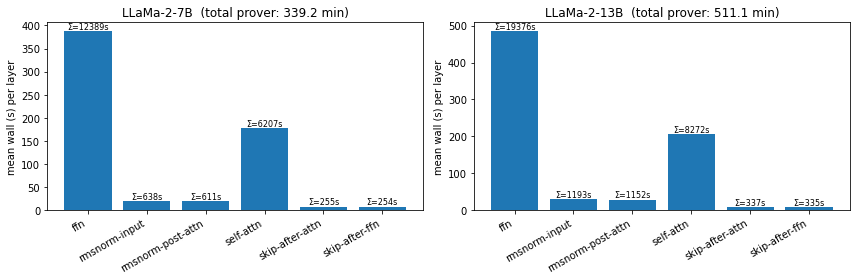

In [35]:
# Cell 15 — Per-stage timing breakdown plot.
import json
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(MODEL_SIZES), figsize=(6*len(MODEL_SIZES), 4), squeeze=False)
for ax, n in zip(axes[0], MODEL_SIZES):
    jsonl = RESULTS_DIR / f'stage_metrics_{n}b.jsonl'
    if not jsonl.exists():
        ax.set_title(f'{n}B (no data)'); continue
    rows = [json.loads(l) for l in open(jsonl)]
    by_label = {}
    for r in rows:
        by_label.setdefault(r['label'], []).append(r['wall_s'])
    labels = sorted(by_label)
    means  = [sum(by_label[k])/len(by_label[k]) for k in labels]
    totals = [sum(by_label[k]) for k in labels]
    bars = ax.bar(range(len(labels)), means)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_ylabel('mean wall (s) per layer')
    ax.set_title(f'LLaMa-2-{n}B  (total prover: {sum(totals)/60:.1f} min)')
    for b, t in zip(bars, totals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'Σ={t:.0f}s',
                ha='center', va='bottom', fontsize=8)
fig.tight_layout()
out_png = RESULTS_DIR / 'stage_breakdown.png'
fig.savefig(out_png, dpi=120)
print(f'wrote {out_png}')
plt.show()

In [36]:
# Cell 16 — Final summary blob (everything in one JSON, easy to copy back here on remote runs).
summary = {
    'config': dict(MODEL_SIZES=MODEL_SIZES, SEQ_LEN=SEQ_LEN, LOG_SF=LOG_SF,
                    GPU_ARCH=GPU_ARCH, LAYER_LIMIT=LAYER_LIMIT,
                    RUN_PERPLEXITY=RUN_PERPLEXITY,
                    PERPLEXITY_SAMPLES=PERPLEXITY_SAMPLES),
    'commit_metrics'   : commit_metrics,
    'pipeline_metrics' : pipeline_metrics,
    'verifier_metrics' : verifier_metrics,
    'perplexity'       : perplexity_results,
    'layer_counts'     : layer_counts,
    'embed_dims'       : embed_dims,
}
out_json = RESULTS_DIR / 'summary.json'
out_json.write_text(json.dumps(summary, indent=2, default=str))
print(f'wrote {out_json}')
print(json.dumps(summary, indent=2, default=str))

wrote /lambda/nfs/zero-knowledge-virginia/zkllm-ccs2024-fixed/results/summary.json
{
  "config": {
    "MODEL_SIZES": [
      7,
      13
    ],
    "SEQ_LEN": 2048,
    "LOG_SF": 16,
    "GPU_ARCH": "sm_80",
    "LAYER_LIMIT": null,
    "RUN_PERPLEXITY": true,
    "PERPLEXITY_SAMPLES": 64
  },
  "commit_metrics": {
    "7": {
      "wall_s": 1823.1021336989998,
      "commit_size_MB": 5.6337890625,
      "num_files": 288,
      "max_quant_err": 7.62939453125e-06,
      "peak_mem_mb": 22931.0
    },
    "13": {
      "wall_s": 3612.4196373980003,
      "commit_size_MB": 11.260986328125,
      "num_files": 360,
      "max_quant_err": 7.62939453125e-06,
      "peak_mem_mb": 26339.0
    }
  },
  "pipeline_metrics": {
    "7": {
      "prover_wall_s": 20353.721682679985,
      "peak_gpu_mb": 29785.0,
      "proof_size_kB": 166685.7109375,
      "num_stages": 195,
      "num_layers": 32
    },
    "13": {
      "prover_wall_s": 30665.54218668707,
      "peak_gpu_mb": 38827.0,
      "proof_s